<a href="https://colab.research.google.com/github/fasih779/deep-learning/blob/master/EnglishtoUrduTranslatorusing_encoder_decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd

# Read English corpus line by line
with open('/content/Dataset/english-corpus.txt', 'r', encoding='utf-8') as f:
    english_lines = [line.strip() for line in f]
english_df = pd.DataFrame(english_lines, columns=['English'])

# Read Urdu corpus line by line
with open('/content/Dataset/urdu-corpus.txt', 'r', encoding='utf-8') as f:
    urdu_lines = [line.strip() for line in f]
urdu_df = pd.DataFrame(urdu_lines, columns=['Urdu'])

# See top 5 rows
print(english_df.head())
print(urdu_df.head())

                English
0   is zain your nephew
1  i wish youd trust me
2      did he touch you
3      its part of life
4        zain isnt ugly
                        Urdu
0      زین تمہارا بھتیجا ہے۔
1  کاش تم مجھ پر بھروسہ کرتے
2      کیا اس نے آپ کو چھوا؟
3         اس کی زندگی کا حصہ
4        زین بدصورت نہیں ہے۔


In [59]:
urdu_df=urdu_df.iloc[:500]
english_df=english_df.iloc[:500]

In [60]:
from numpy import e
urdu_df.head(2)
english_df.head(2)

,English
0,is zain your nephew
1,i wish youd trust me


In [61]:
urdu_df.head(2)


,Urdu
0,زین تمہارا بھتیجا ہے۔
1,کاش تم مجھ پر بھروسہ کرتے


In [62]:
df = pd.concat([english_df, urdu_df], axis=1)


In [63]:
df.head(2)

,English,Urdu
0,is zain your nephew,زین تمہارا بھتیجا ہے۔
1,i wish youd trust me,کاش تم مجھ پر بھروسہ کرتے


In [64]:
df.drop_duplicates()

,English,Urdu
0,is zain your nephew,زین تمہارا بھتیجا ہے۔
1,i wish youd trust me,کاش تم مجھ پر بھروسہ کرتے
2,did he touch you,کیا اس نے آپ کو چھوا؟
3,its part of life,اس کی زندگی کا حصہ
4,zain isnt ugly,زین بدصورت نہیں ہے۔
...,...,...
495,i ask you,میں آپ سے پوچھتا ہوں
496,its hopeless,یہ نا امید ہے
497,i want to eat this,میں یہ کھانا چاہتا ہوں۔
498,black is depressing,سیاہ افسردہ ہے


In [65]:
df.dropna(inplace=True)

In [66]:
df['Urdu'] = df['Urdu'].apply(lambda x: "<start> " + x + " <end>")

In [67]:
df.head(2)

,English,Urdu
0,is zain your nephew,<start> زین تمہارا بھتیجا ہے۔ <end>
1,i wish youd trust me,<start> کاش تم مجھ پر بھروسہ کرتے <end>


In [68]:
from sklearn.model_selection import train_test_split


In [69]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)


In [70]:
train_df

,English,Urdu
249,i had like to stay here,<start> مجھے یہاں رہنا پسند تھا۔ <end>
433,i feel sorry for her,<start> مجھے اس کے لیے افسوس ہے۔ <end>
19,is it for here,<start> کیا یہ یہاں کے لیے ہے؟ <end>
322,what is this key for,<start> یہ چابی کس کے لیے ہے؟ <end>
332,i have two cats,<start> میرے پاس دو بلیاں ہیں۔ <end>
...,...,...
106,lets keep quiet,<start> خاموش رہنے دو <end>
270,i keep thirteen cats,<start> میں تیرہ بلیاں رکھتا ہوں۔ <end>
348,i nearly died,<start> میں تقریبا مر گیا <end>
435,she cant afford it,<start> وہ اسے برداشت نہیں کر سکتا <end>


In [71]:
eng_tokenizer = Tokenizer(lower=True)
eng_tokenizer.fit_on_texts(train_df['English'])
input_sequences = eng_tokenizer.texts_to_sequences(train_df['English'])
input_maxlen = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=input_maxlen, padding='post')


urdu_tokenizer = Tokenizer( lower=False)
urdu_tokenizer.fit_on_texts(train_df['Urdu'])
target_sequences = urdu_tokenizer.texts_to_sequences(train_df['Urdu'])
target_maxlen = max(len(seq) for seq in target_sequences)
target_sequences = pad_sequences(target_sequences, maxlen=target_maxlen, padding='post')

eng_vocab_size = len(eng_tokenizer.word_index) + 1
urdu_vocab_size = len(urdu_tokenizer.word_index) + 1

In [76]:
eng_vocab_size

581

In [72]:
from tensorflow.keras.layers import Input, Embedding, LSTM


In [80]:
encoder_inputs = Input(shape=(input_maxlen,))
encoder_embedding = Embedding(eng_vocab_size, 256)(encoder_inputs)
LSTM_encoder = LSTM(256,return_sequences=True ,return_state=True)
output_encoder, state_h, state_c = LSTM_encoder(encoder_embedding)
s0=[state_h,state_c]

In [102]:
decoder_inputs = Input(shape=(target_maxlen - 1,))
decoder_embedding = Embedding(
        urdu_vocab_size,
        256,
)(decoder_inputs)
LSTM_decoder = LSTM(256, return_sequences=True, return_state=True)

In [104]:
output_decoder, _, _ = LSTM_decoder(decoder_embedding, initial_state=s0)

In [105]:
from tensorflow.keras.layers import Attention

In [106]:
attention_layer = Attention()

In [107]:
context_vector = attention_layer(
    [output_decoder, output_encoder]
)

In [108]:
from tensorflow.keras.layers import Concatenate

In [109]:
concat_layer = Concatenate(axis=-1)

decoder_combined_context = concat_layer(
    [output_decoder, context_vector]
)

In [110]:
from tensorflow.keras.layers import Dense

output_layer = Dense(urdu_vocab_size, activation='softmax')

decoder_outputs = output_layer(decoder_combined_context)

In [111]:
from tensorflow.keras.models import Model

In [112]:
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

In [113]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [114]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 9, 256)    │    148,736 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 13, 256)   │    163,840 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 9, 256),  │    525,312 │ embedding_2[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 13, 256), │    525,312 │ embedding_5[0][0… │
│                     │ (None, 256),      │            │ lstm_2[0][1],     │
│                     │ (None, 256)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 13, 256)   │          0 │ lstm_4[0][0],     │
│ (Attention)         │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 13, 512)   │          0 │ lstm_4[0][0],     │
│ (Concatenate)       │                   │            │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 13, 640)   │    328,320 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,691,520 (6.45 MB)

 Trainable params: 1,691,520 (6.45 MB)

 Non-trainable params: 0 (0.00 B)

In [116]:
history = model.fit(
    [input_sequences, target_sequences[:, :-1]],  # inputs
    target_sequences[:, 1:],  # targets, shifted by one timestep
    batch_size=64,
    epochs=100,
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6652 - loss: 1.6381
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6669 - loss: 1.6114
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6708 - loss: 1.5773
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6777 - loss: 1.5439
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6810 - loss: 1.5127
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6881 - loss: 1.4739
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6938 - loss: 1.4368
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6977 - loss: 1.4040
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7033 - loss: 1.3629
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7100 - loss: 1.3287
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7162 - loss: 1.2829
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7187 - lo

In [117]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Model Loss')

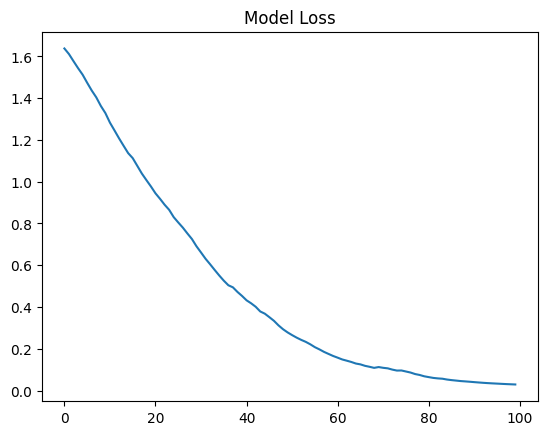

In [118]:
plt.plot(history.history['loss'])
plt.title('Model Loss')

In [135]:
import numpy as np

def urdutoenglish(sentence):
   sentence_sequence = eng_tokenizer.texts_to_sequences([sentence])
   sentence_padded = pad_sequences(sentence_sequence, maxlen=input_maxlen, padding='post')

   encoder_embedding_layer = model.get_layer('embedding_2')
   encoder_lstm_layer = model.get_layer('lstm_2')
   decoder_embedding_layer = model.get_layer('embedding_5')
   decoder_lstm_layer = model.get_layer('lstm_4')
   attention_layer_instance = model.get_layer('attention_1')
   concat_layer_instance = model.get_layer('concatenate_2')
   output_dense_layer_instance = model.get_layer('dense_1')


   embedded_input = encoder_embedding_layer(sentence_padded)
   encoder_output_inf, state_h_inf, state_c_inf = encoder_lstm_layer(embedded_input)
   s0_prediction_inf = [state_h_inf, state_c_inf]

   start_token_index = urdu_tokenizer.word_index.get('<start>', 1)
   target_seq = np.zeros((1, 1))
   target_seq[0, 0] = start_token_index

   translated_sentence = []

   for _ in range(target_maxlen):
       embedded_target = decoder_embedding_layer(target_seq)

       output_decoder_inf, h_inf, c_inf = decoder_lstm_layer(embedded_target, initial_state=s0_prediction_inf)

       context_vector_pred = attention_layer_instance([output_decoder_inf, encoder_output_inf])

       decoder_combined_context_pred = concat_layer_instance([output_decoder_inf, context_vector_pred])

       output_tokens = output_dense_layer_instance(decoder_combined_context_pred)

       predicted_token_index = np.argmax(output_tokens[0, -1, :])

       predicted_word = urdu_tokenizer.index_word.get(predicted_token_index, '')

       if predicted_word == '<end>':
           break
       if predicted_word != '<start>':
           translated_sentence.append(predicted_word)

       target_seq = np.zeros((1, 1))
       target_seq[0, 0] = predicted_token_index
       s0_prediction_inf = [h_inf, c_inf]

   return ' '.join(translated_sentence)

In [140]:
urdutoenglish("i feel sorry for her")

'مجھے اس کے لیے افسوس ہے۔ end       '